# Iris Flower Classification using Decision Tree (CSV)

**Repositori**: Machine Learning  
**Topik**: Klasifikasi Spesies Bunga Iris dengan Decision Tree (Dataset CSV)  
**Dataset**: `Dataset Iris.csv`  

---

## Pendahuluan
Proyek ini menggunakan **Decision Tree** untuk mengklasifikasikan spesies bunga Iris berdasarkan 4 fitur morfologis. Dataset hanya berisi 2 kelas: **Iris-versicolor** (50 baris) dan **Iris-virginica** (50 baris). Kelas **Iris-setosa** tidak tersedia dalam CSV ini, sehingga ini adalah klasifikasi biner.

### Pipeline:
1. **Data Acquisition** — Muat CSV
2. **EDA** — Analisis distribusi data
3. **Data Preparation** — Encode label, drop ID, split train/test
4. **Modeling** — Decision Tree
5. **Evaluation** — Confusion Matrix + Classification Report

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Acquisition

In [2]:
df = pd.read_csv('../../data/Dataset Iris.csv', delimiter=';')
print(f"Shape: {df.shape}")
df.head()

Shape: (100, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,7.00,3.02,4.07,1.04,Iris-versicolor
1,2,6.04,3.02,4.05,1.05,Iris-versicolor
2,3,6.09,3.01,4.09,1.05,Iris-versicolor
3,4,5.05,2.03,4.00,1.03,Iris-versicolor
4,5,6.05,2.08,4.06,1.05,Iris-versicolor


## 2. Exploratory Data Analysis

In [3]:
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nDistribusi Species:")
print(df['Species'].value_counts())

print("\nCatatan: Dataset hanya berisi Iris-versicolor dan Iris-virginica.")
print("Kelas Iris-setosa tidak tersedia (binary classification).")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB

Statistik Deskriptif:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  100.000000     100.000000    100.000000     100.000000    100.000000
mean    50.500000       5.828200      2.492200       4.504600      1.328600
std     29.011492       0.682243      0.476052       0.828199      0.445877
min      1.000000       4.090000      2.000000       3.000000      1.000000
25%     25.750000       5.080000      2.070000       4.037500

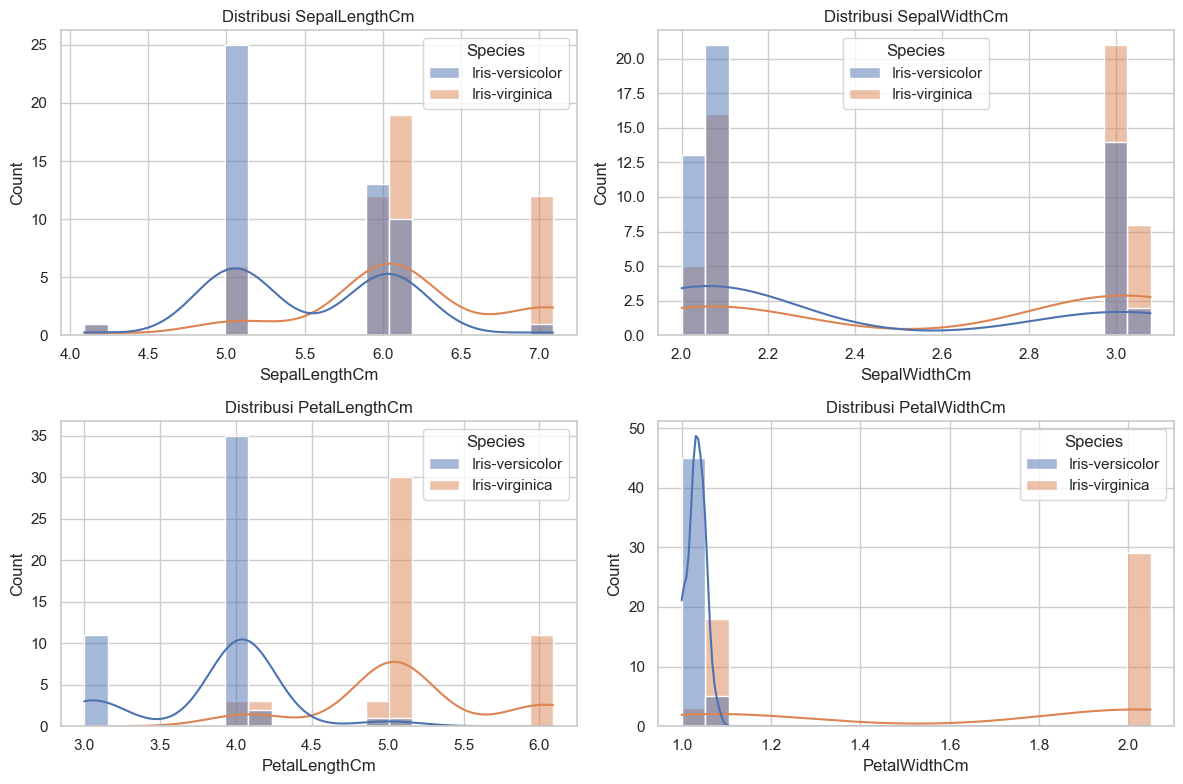

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, hue='Species', bins=20, kde=True, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

## 3. Data Preparation
Encoding label, drop kolom ID, lalu split.

In [5]:
df['Species'] = pd.factorize(df['Species'])[0]  # Iris-versicolor=0, Iris-virginica=1
df = df.drop(labels='Id', axis=1)

X = df[feature_cols].values
y = df['Species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 80 samples
Test size:  20 samples


## 4. Model Training

In [6]:
model = DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)
print("Model trained:", model)

Model trained: DecisionTreeClassifier(random_state=0)


## 5. Prediction & Evaluation

Confusion Matrix:
[[10  0]
 [ 0 10]]


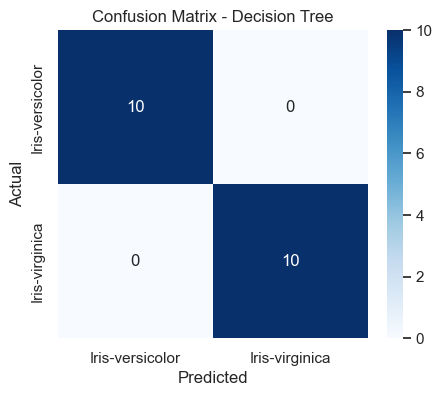


Classification Report:
                 precision    recall  f1-score   support

Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20

Accuracy: 20/20 = 100.0%


In [7]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Iris-versicolor', 'Iris-virginica'],
            yticklabels=['Iris-versicolor', 'Iris-virginica'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Iris-versicolor', 'Iris-virginica']))

# Manual accuracy check
correct = (y_pred == y_test).sum()
total = len(y_test)
print(f"Accuracy: {correct}/{total} = {correct/total*100:.1f}%")

## Kesimpulan
Decision Tree berhasil mengklasifikasikan Iris-versicolor vs Iris-virginica dengan akurasi sempurna pada test set (20 sampel). Dataset ini hanya mencakup 2 dari 3 spesies Iris — untuk klasifikasi 3 kelas lengkap, gunakan dataset Iris standar dari Scikit-Learn (`sklearn.datasets.load_iris()`).